In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import contextlib
import joblib
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.feature_selection import VarianceThreshold, SelectFromModel, RFE
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, auc, roc_curve
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.stats import mannwhitneyu, loguniform, randint
from xgboost import XGBClassifier
from tqdm.auto import tqdm
from worcgist.load_data import load_data
warnings.filterwarnings('ignore')

In [2]:
# Data loading functions.
data = load_data()
print(f'The number of samples: {len(data.index)}')
print(f'The number of columns: {len(data.columns)}')

The number of samples: 246
The number of columns: 494



Label encoding mapping: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}

Training set size: 196 samples
Testing set size: 50 samples
Starting Nested Cross-Validation...


Outer CV Folds:   0%|          | 0/5 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


Outer CV Folds:  20%|██        | 1/5 [00:40<02:40, 40.19s/it]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


...

Outer CV Folds:  60%|██████    | 3/5 [01:45<01:14, 37.13s/it]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


Outer CV Folds:  80%|████████  | 4/5 [02:37<00:42, 42.91s/it]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


Outer CV Folds: 100%|██████████| 5/5 [02:50<00:00, 34.04s/it]


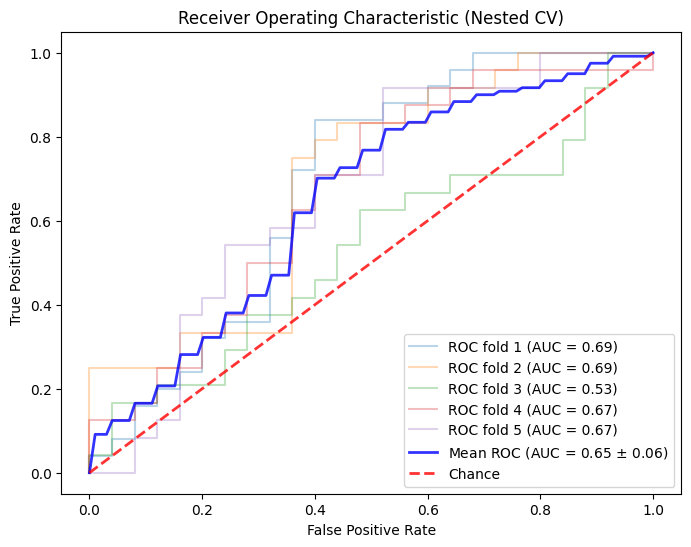


--- Summary of Best Models per Outer Fold ---


,Fold,Classifier,Feature Selector,Outer Accuracy,Outer AUC
0,1,RandomForestClassifier,None,0.6000,0.6880
1,2,RandomForestClassifier,MannWhitneyFilter,0.6735,0.6900
2,3,RandomForestClassifier,None,0.5306,0.5317
3,4,RandomForestClassifier,MannWhitneyFilter,0.5714,0.6667
4,5,RandomForestClassifier,MannWhitneyFilter,0.6122,0.6717



--- Winning Hyperparameters per Fold ---

Fold 1: RandomForestClassifier + None
   - classifier: RandomForestClassifier
   - classifier__max_depth: 10
   - classifier__n_estimators: 199
   - feature_selection: passthrough

Fold 2: RandomForestClassifier + MannWhitneyFilter
   - classifier: RandomForestClassifier
   - classifier__max_depth: 2
   - classifier__n_estimators: 64
   - feature_selection: MannWhitneyFilter
   - feature_selection__n_features_to_select: 15

Fold 3: RandomForestClassifier + None
   - classifier: RandomForestClassifier
   - classifier__max_depth: 10
   - classifier__n_estimators: 199
   - feature_selection: passthrough

Fold 4: RandomForestClassifier + MannWhitneyFilter
   - classifier: RandomForestClassifier
   - classifier__max_depth: 2
   - classifier__n_estimators: 64
   - feature_selection: MannWhitneyFilter
   - feature_selection__n_features_to_select: 15

Fold 5: RandomForestClassifier + MannWhitneyFilter
   - classifier: RandomForestClassifier
   - class

In [14]:

# ---------------------------------------------------------
# 1. Custom Transformers
# ---------------------------------------------------------
class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.90):
        self.threshold = threshold
        self.to_drop = []

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        corr_matrix = X_df.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        self.to_drop = [column for column in upper.columns if any(upper[column] > self.threshold)]
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X)
        return X_df.drop(columns=self.to_drop)

class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, limits=(0.01, 0.01)):
        self.limits = limits
        self.lower_bounds_ = None
        self.upper_bounds_ = None

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        lower_quantile = self.limits[0]
        upper_quantile = 1.0 - self.limits[1]
        self.lower_bounds_ = X_df.quantile(lower_quantile)
        self.upper_bounds_ = X_df.quantile(upper_quantile)
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X)
        X_winsorized = X_df.clip(lower=self.lower_bounds_, upper=self.upper_bounds_, axis=1)
        return X_winsorized

class MannWhitneyFilter(BaseEstimator, TransformerMixin):
    def __init__(self, n_features_to_select=10):
        self.n_features_to_select = n_features_to_select
        self.selected_indices_ = []

    def fit(self, X, y):
        X_df = pd.DataFrame(X)
        y_arr = np.array(y)
        class_0 = X_df[y_arr == 0]
        class_1 = X_df[y_arr == 1]
        p_values = []

        for col in X_df.columns:
            stat, p_val = mannwhitneyu(class_0[col], class_1[col], alternative='two-sided')
            p_values.append((col, p_val))

        p_values.sort(key=lambda x: x[1])
        k = min(self.n_features_to_select, len(X_df.columns))
        self.selected_indices_ = [item[0] for item in p_values[:k]]
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X)
        return X_df[self.selected_indices_]

# ---------------------------------------------------------
# 2. Data Preparation
# ---------------------------------------------------------
label_encoder = LabelEncoder()
data['label'] = label_encoder.fit_transform(data['label'])
print(f'\nLabel encoding mapping: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}')

# Train-test split (80-20 split, stratify on label)
X = data.drop(['label'], axis=1)
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'\nTraining set size: {X_train.shape[0]} samples')
print(f'Testing set size: {X_test.shape[0]} samples')

# ---------------------------------------------------------
# 3. Dictionaries & Distributions
# ---------------------------------------------------------
feature_selectors = {
    'Mann-Whitney U-Test': MannWhitneyFilter(),
    'LASSO': SelectFromModel(LogisticRegression(penalty='l1', solver='liblinear', random_state=42)),
    'RFE_LR': RFE(estimator=LogisticRegression(random_state=42), step=0.05),
    'None': 'passthrough'
}

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

param_distributions = [
    # Logistic Regression
    {
        'feature_selection': [feature_selectors['LASSO']],
        'feature_selection__estimator__C': loguniform(0.01, 10),
        'classifier': [classifiers['Logistic Regression']],
        'classifier__C': loguniform(0.001, 100),
        'classifier__penalty': ['l1', 'l2'],
        'classifier__solver': ['liblinear']
    },
    {
        'feature_selection': [feature_selectors['RFE_LR']],
        'feature_selection__n_features_to_select': randint(5, 25),
        'classifier': [classifiers['Logistic Regression']],
        'classifier__C': loguniform(0.001, 100),
        'classifier__penalty': ['l1', 'l2'],
        'classifier__solver': ['liblinear']
    },
    {
        'feature_selection': [feature_selectors['Mann-Whitney U-Test']],
        'feature_selection__n_features_to_select': randint(5, 25),
        'classifier': [classifiers['Logistic Regression']],
        'classifier__C': loguniform(0.01, 10),
        'classifier__penalty': ['l1', 'l2'],
        'classifier__solver': ['liblinear']
    },
    {
        'feature_selection': [feature_selectors['None']],
        'classifier': [classifiers['Logistic Regression']],
        'classifier__C': loguniform(0.01, 10),
        'classifier__penalty': ['l1', 'l2'],
        'classifier__solver': ['liblinear']
    },

    # Random Forest
    {
        'feature_selection': [feature_selectors['LASSO']],
        'feature_selection__estimator__C': loguniform(0.01, 10),
        'classifier': [classifiers['Random Forest']],
        'classifier__n_estimators': randint(50, 200),
        'classifier__max_depth': [2, 5, 10]
    },
    {
        'feature_selection': [feature_selectors['RFE_LR']],
        'feature_selection__n_features_to_select': randint(5, 25),
        'classifier': [classifiers['Random Forest']],
        'classifier__n_estimators': randint(50, 200),
        'classifier__max_depth': [2, 5, 10]
    },
    {
        'feature_selection': [feature_selectors['Mann-Whitney U-Test']],
        'feature_selection__n_features_to_select': randint(5, 25),
        'classifier': [classifiers['Random Forest']],
        'classifier__n_estimators': randint(50, 200),
        'classifier__max_depth': [2, 5, 10]
    },
    {
        'feature_selection': [feature_selectors['None']],
        'classifier': [classifiers['Random Forest']],
        'classifier__n_estimators': randint(50, 200),
        'classifier__max_depth': [2, 5, 10]
    },

    # SVM
    {
        'feature_selection': [feature_selectors['LASSO']],
        'feature_selection__estimator__C': loguniform(0.01, 10),
        'classifier': [classifiers['SVM']],
        'classifier__C': loguniform(0.01, 100),
        'classifier__kernel': ['linear', 'rbf']
    },
    {
        'feature_selection': [feature_selectors['RFE_LR']],
        'feature_selection__n_features_to_select': randint(5, 25),
        'classifier': [classifiers['SVM']],
        'classifier__C': loguniform(0.01, 100),
        'classifier__kernel': ['linear', 'rbf']
    },
    {
        'feature_selection': [feature_selectors['Mann-Whitney U-Test']],
        'feature_selection__n_features_to_select': randint(5, 25),
        'classifier': [classifiers['SVM']],
        'classifier__C': loguniform(0.01, 100),
        'classifier__kernel': ['linear', 'rbf']
    },
    {
        'feature_selection': [feature_selectors['None']],
        'classifier': [classifiers['SVM']],
        'classifier__C': loguniform(0.01, 100),
        'classifier__kernel': ['linear', 'rbf']
    },

    # XGBoost
    {
        'feature_selection': [feature_selectors['LASSO']],
        'feature_selection__estimator__C': loguniform(0.01, 10),
        'classifier': [classifiers['XGBoost']],
        'classifier__n_estimators': randint(50, 200),
        'classifier__max_depth': [2, 3, 4],
        'classifier__learning_rate': loguniform(0.01, 0.2),
        'classifier__subsample': [0.6,0.8, 1.0]

        
    },
    {
        'feature_selection': [feature_selectors['RFE_LR']],
        'feature_selection__n_features_to_select': randint(10, 101),
        'classifier': [classifiers['XGBoost']],
        'classifier__n_estimators': randint(50, 200),
        'classifier__max_depth': [2, 3, 4],
        'classifier__learning_rate': loguniform(0.01, 0.2),
        'classifier__subsample': [0.6,0.8, 1.0]
    },
    {
        'feature_selection': [feature_selectors['Mann-Whitney U-Test']],
        'feature_selection__n_features_to_select': randint(10, 101),
        'classifier': [classifiers['XGBoost']],
        'classifier__n_estimators': randint(50, 200),
        'classifier__max_depth': [2, 3, 4],
        'classifier__learning_rate': loguniform(0.01, 0.2),
        'classifier__subsample': [0.6,0.8, 1.0]
    },
    {
        'feature_selection': [feature_selectors['None']],
        'classifier': [classifiers['XGBoost']],
        'classifier__n_estimators': randint(50, 200),
        'classifier__max_depth': [2, 3, 4],
        'classifier__learning_rate': loguniform(0.01, 0.2),
        'classifier__subsample': [0.6,0.8, 1.0]
    }
]


# ---------------------------------------------------------
# 4. Pipeline & Search Setup
# ---------------------------------------------------------
pipeline = Pipeline([
    ('variance_thresh', VarianceThreshold(threshold=0).set_output(transform="pandas")),
    ('scaler', RobustScaler().set_output(transform="pandas")),
    ('winsorizer', Winsorizer(limits=(0.01, 0.01))),
    ('corr_filter', CorrelationFilter(threshold=0.90)),
    ('feature_selection', 'passthrough'), 
    ('classifier', 'passthrough')        
])


inner_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Number of random combinations to test
N_ITER = 10

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=N_ITER,
    cv=inner_cv,
    scoring=['accuracy', 'roc_auc'],
    refit='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

#Nested loop

print("Starting Nested Cross-Validation...")

# Define the outer CV
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store metrics for plotting and the final table
fold_results = []
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

# Setup the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Execute the manual outer loop
# We use tqdm here to show progress across the 5 outer folds
for fold, (train_idx, test_idx) in enumerate(tqdm(outer_cv.split(X, y), total=outer_cv.get_n_splits(), desc="Outer CV Folds")):
    
    # Split the data for this specific fold
    # Note: Use .iloc if X and y are Pandas DataFrames/Series to avoid index errors
    X_train_outer, X_test_outer = X.iloc[train_idx], X.iloc[test_idx]
    y_train_outer, y_test_outer = y.iloc[train_idx], y.iloc[test_idx]
    
    # Run the inner RandomizedSearchCV to find the best model for this training fold
    random_search.fit(X_train_outer, y_train_outer)
    
    # Extract the best model
    best_model = random_search.best_estimator_
    best_params = random_search.best_params_
    
    # Evaluate the best model on the hidden outer test fold
    y_pred = best_model.predict(X_test_outer)
    y_prob = best_model.predict_proba(X_test_outer)[:, 1]
    
    # Calculate fold metrics
    fold_acc = accuracy_score(y_test_outer, y_pred)
    fpr, tpr, thresholds = roc_curve(y_test_outer, y_prob)
    fold_auc = auc(fpr, tpr)
    
    # Save the ROC curve data for the mean plot later
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(fold_auc)
    
    # Plot the ROC curve for this specific fold
    ax.plot(fpr, tpr, alpha=0.3, label=f'ROC fold {fold+1} (AUC = {fold_auc:.2f})')
    
    # Clean up the best_params dictionary for the table (make it easier to read)
    classifier_name = str(best_model.named_steps['classifier'].__class__.__name__)
    feature_selector_name = str(best_model.named_steps['feature_selection'].__class__.__name__)
    if feature_selector_name == "str": # Handles the 'passthrough' string
        feature_selector_name = "None"
        
    # Store the results for the summary table
    fold_results.append({
        'Fold': fold + 1,
        'Classifier': classifier_name,
        'Feature Selector': feature_selector_name,
        'Outer Accuracy': round(fold_acc, 4),
        'Outer AUC': round(fold_auc, 4),
        'Best Params (Raw)': best_params
    })

# Plot the Mean ROC curve
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

ax.plot(mean_fpr, mean_tpr, color='b',
        label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
        lw=2, alpha=0.8)

# Plot the random chance line (diagonal)
ax.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=0.8)

# Finalize the plot formatting
ax.set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05],
       title="Receiver Operating Characteristic (Nested CV)")
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc="lower right")
plt.show()

# ---------------------------------------------------------
# 6. Summary Table Output
# ---------------------------------------------------------
print("\n--- Summary of Best Models per Outer Fold ---")
results_df = pd.DataFrame(fold_results)

# Display the clean table
display(results_df.drop(columns=['Best Params (Raw)']))

# Display the winning hyperparameters for each fold
print("\n--- Winning Hyperparameters per Fold ---")
for index, row in results_df.iterrows():
    print(f"\nFold {row['Fold']}: {row['Classifier']} + {row['Feature Selector']}")
    #Iterate through the dictionary and print the exact parameter names
    for param_name, param_value in row['Best Params (Raw)'].items():
        # If the value is a complex object (like the classifier itself), print its class name
        if hasattr(param_value, '__class__') and not isinstance(param_value, (int, float, str, bool, type(None))):
            print(f"   - {param_name}: {param_value.__class__.__name__}")
        elif isinstance(param_value, float):
            # Format floats to 4 decimal places for readability
            print(f"   - {param_name}: {param_value:.4f}")
        else:
            # Print strings, ints, and booleans exactly as they are
            print(f"   - {param_name}: {param_value}")

# Calculate and print the unbiased overall metrics
print("\n--- Unbiased Overall Performance ---")
print(f"Mean Nested Accuracy: {results_df['Outer Accuracy'].mean():.4f} (+/- {results_df['Outer Accuracy'].std():.4f})")
print(f"Mean Nested AUC:      {results_df['Outer AUC'].mean():.4f} (+/- {results_df['Outer AUC'].std():.4f})")


Label encoding mapping: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}

Training set size: 196 samples
Testing set size: 50 samples
Starting Nested Cross-Validation...


Outer CV Folds:   0%|          | 0/5 [00:00<?, ?it/s]

Fitting 10 folds for each of 1398 candidates, totalling 13980 fits


Outer CV Folds:  20%|██        | 1/5 [25:50<1:43:21, 1550.25s/it]

Fitting 10 folds for each of 1398 candidates, totalling 13980 fits


...

Outer CV Folds:  60%|██████    | 3/5 [2:04:00<1:26:08, 2584.03s/it]

Fitting 10 folds for each of 1398 candidates, totalling 13980 fits


Outer CV Folds:  80%|████████  | 4/5 [3:35:44<1:02:16, 3736.61s/it]

Fitting 10 folds for each of 1398 candidates, totalling 13980 fits


Outer CV Folds: 100%|██████████| 5/5 [4:02:56<00:00, 2915.35s/it]  


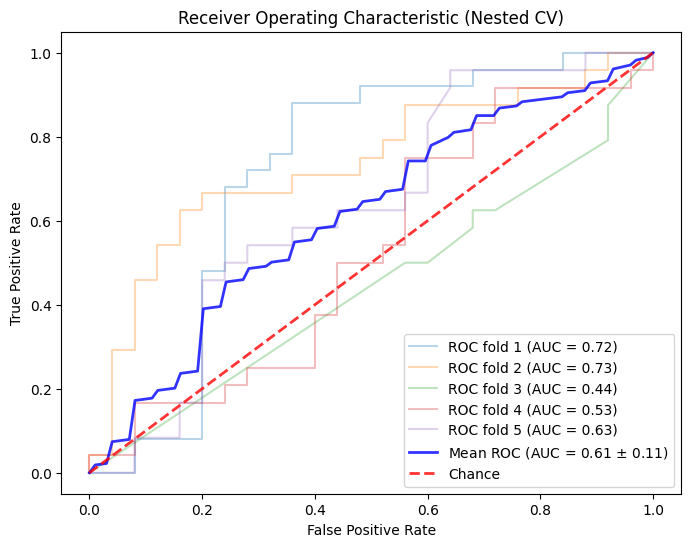


--- Summary of Best Models per Outer Fold ---


,Fold,Classifier,Feature Selector,Outer Accuracy,Outer AUC
0,1,XGBClassifier,RFE,0.7200,0.7184
1,2,XGBClassifier,RFE,0.6327,0.7350
2,3,XGBClassifier,SelectFromModel,0.4694,0.4450
3,4,XGBClassifier,None,0.4898,0.5267
4,5,XGBClassifier,MannWhitneyFilter,0.5714,0.6283



--- Winning Hyperparameters per Fold ---

Fold 1: XGBClassifier + RFE
   - classifier: XGBClassifier
   - classifier__learning_rate: 0.1000
   - classifier__max_depth: 4
   - classifier__n_estimators: 200
   - classifier__subsample: 1.0000
   - feature_selection: RFE
   - feature_selection__n_features_to_select: 100

Fold 2: XGBClassifier + RFE
   - classifier: XGBClassifier
   - classifier__learning_rate: 0.2000
   - classifier__max_depth: 2
   - classifier__n_estimators: 100
   - classifier__subsample: 0.8000
   - feature_selection: RFE
   - feature_selection__n_features_to_select: 70

Fold 3: XGBClassifier + SelectFromModel
   - classifier: XGBClassifier
   - classifier__learning_rate: 0.0100
   - classifier__max_depth: 2
   - classifier__n_estimators: 50
   - classifier__subsample: 1.0000
   - feature_selection: SelectFromModel
   - feature_selection__estimator__C: 0.1000

Fold 4: XGBClassifier + None
   - classifier: XGBClassifier
   - classifier__learning_rate: 0.2000
   - class

In [16]:

# ---------------------------------------------------------
# 1. Custom Transformers
# ---------------------------------------------------------
class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.90):
        self.threshold = threshold
        self.to_drop = []

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        corr_matrix = X_df.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        self.to_drop = [column for column in upper.columns if any(upper[column] > self.threshold)]
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X)
        return X_df.drop(columns=self.to_drop)

class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, limits=(0.01, 0.01)):
        self.limits = limits
        self.lower_bounds_ = None
        self.upper_bounds_ = None

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        lower_quantile = self.limits[0]
        upper_quantile = 1.0 - self.limits[1]
        self.lower_bounds_ = X_df.quantile(lower_quantile)
        self.upper_bounds_ = X_df.quantile(upper_quantile)
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X)
        X_winsorized = X_df.clip(lower=self.lower_bounds_, upper=self.upper_bounds_, axis=1)
        return X_winsorized

class MannWhitneyFilter(BaseEstimator, TransformerMixin):
    def __init__(self, n_features_to_select=10):
        self.n_features_to_select = n_features_to_select
        self.selected_indices_ = []

    def fit(self, X, y):
        X_df = pd.DataFrame(X)
        y_arr = np.array(y)
        class_0 = X_df[y_arr == 0]
        class_1 = X_df[y_arr == 1]
        p_values = []

        for col in X_df.columns:
            stat, p_val = mannwhitneyu(class_0[col], class_1[col], alternative='two-sided')
            p_values.append((col, p_val))

        p_values.sort(key=lambda x: x[1])
        k = min(self.n_features_to_select, len(X_df.columns))
        self.selected_indices_ = [item[0] for item in p_values[:k]]
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X)
        return X_df[self.selected_indices_]

# ---------------------------------------------------------
# 2. Data Preparation
# ---------------------------------------------------------
label_encoder = LabelEncoder()
data['label'] = label_encoder.fit_transform(data['label'])
print(f'\nLabel encoding mapping: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}')

# Train-test split (80-20 split, stratify on label)
X = data.drop(['label'], axis=1)
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'\nTraining set size: {X_train.shape[0]} samples')
print(f'Testing set size: {X_test.shape[0]} samples')

# ---------------------------------------------------------
# 3. Dictionaries & Distributions
# ---------------------------------------------------------
feature_selectors = {
    'Mann-Whitney U-Test': MannWhitneyFilter(),
    'LASSO': SelectFromModel(LogisticRegression(penalty='l1', solver='liblinear', random_state=42)),
    'RFE_LR': RFE(estimator=LogisticRegression(random_state=42), step=0.05),
    'None': 'passthrough'
}

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

param_grid = [
    # Logistic Regression
    {
        'feature_selection': [feature_selectors['LASSO']],
        'feature_selection__estimator__C': [0.01, 0.1, 1.0, 10.0],
        'classifier': [classifiers['Logistic Regression']],
        'classifier__C': [0.001, 0.1, 10.0, 100.0],
        'classifier__penalty': ['l1', 'l2'],
        'classifier__solver': ['liblinear']
    },
    {
        'feature_selection': [feature_selectors['RFE_LR']],
        'feature_selection__n_features_to_select': [5, 10, 15, 20, 25],
        'classifier': [classifiers['Logistic Regression']],
        'classifier__C': [0.001, 0.1, 10.0, 100.0],
        'classifier__penalty': ['l1', 'l2'],
        'classifier__solver': ['liblinear']
    },
    {
        'feature_selection': [feature_selectors['Mann-Whitney U-Test']],
        'feature_selection__n_features_to_select': [5, 10, 15, 20, 25],
        'classifier': [classifiers['Logistic Regression']],
        'classifier__C': [0.01, 0.1, 1.0, 10.0],
        'classifier__penalty': ['l1', 'l2'],
        'classifier__solver': ['liblinear']
    },
    {
        'feature_selection': [feature_selectors['None']],
        'classifier': [classifiers['Logistic Regression']],
        'classifier__C': [0.01, 0.1, 1.0, 10.0],
        'classifier__penalty': ['l1', 'l2'],
        'classifier__solver': ['liblinear']
    },

    # Random Forest
    {
        'feature_selection': [feature_selectors['LASSO']],
        'feature_selection__estimator__C': [0.01, 0.1, 1.0, 10.0],
        'classifier': [classifiers['Random Forest']],
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [2, 5, 10]
    },
    {
        'feature_selection': [feature_selectors['RFE_LR']],
        'feature_selection__n_features_to_select': [5, 10, 15, 20, 25],
        'classifier': [classifiers['Random Forest']],
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [2, 5, 10]
    },
    {
        'feature_selection': [feature_selectors['Mann-Whitney U-Test']],
        'feature_selection__n_features_to_select': [5, 10, 15, 20, 25],
        'classifier': [classifiers['Random Forest']],
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [2, 5, 10]
    },
    {
        'feature_selection': [feature_selectors['None']],
        'classifier': [classifiers['Random Forest']],
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [2, 5, 10]
    },

    # SVM
    {
        'feature_selection': [feature_selectors['LASSO']],
        'feature_selection__estimator__C': [0.01, 0.1, 1.0, 10.0],
        'classifier': [classifiers['SVM']],
        'classifier__C': [0.01, 1.0, 100.0],
        'classifier__kernel': ['linear', 'rbf']
    },
    {
        'feature_selection': [feature_selectors['RFE_LR']],
        'feature_selection__n_features_to_select': [5, 10, 15, 20, 25],
        'classifier': [classifiers['SVM']],
        'classifier__C': [0.01, 1.0, 100.0],
        'classifier__kernel': ['linear', 'rbf']
    },
    {
        'feature_selection': [feature_selectors['Mann-Whitney U-Test']],
        'feature_selection__n_features_to_select': [5, 10, 15, 20, 25],
        'classifier': [classifiers['SVM']],
        'classifier__C': [0.01, 1.0, 100.0],
        'classifier__kernel': ['linear', 'rbf']
    },
    {
        'feature_selection': [feature_selectors['None']],
        'classifier': [classifiers['SVM']],
        'classifier__C': [0.01, 1.0, 100.0],
        'classifier__kernel': ['linear', 'rbf']
    },

    # XGBoost
    {
        'feature_selection': [feature_selectors['LASSO']],
        'feature_selection__estimator__C': [0.01, 0.1, 1.0, 10.0],
        'classifier': [classifiers['XGBoost']],
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [2, 3, 4],
        'classifier__learning_rate': [0.01, 0.1, 0.2],
        'classifier__subsample': [0.6, 0.8, 1.0]
    },
    {
        'feature_selection': [feature_selectors['RFE_LR']],
        'feature_selection__n_features_to_select': [10, 40, 70, 100], 
        'classifier': [classifiers['XGBoost']],
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [2, 3, 4],
        'classifier__learning_rate': [0.01, 0.1, 0.2],
        'classifier__subsample': [0.6, 0.8, 1.0]
    },
    {
        'feature_selection': [feature_selectors['Mann-Whitney U-Test']],
        'feature_selection__n_features_to_select': [10, 40, 70, 100],
        'classifier': [classifiers['XGBoost']],
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [2, 3, 4],
        'classifier__learning_rate': [0.01, 0.1, 0.2],
        'classifier__subsample': [0.6, 0.8, 1.0]
    },
    {
        'feature_selection': [feature_selectors['None']],
        'classifier': [classifiers['XGBoost']],
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [2, 3, 4],
        'classifier__learning_rate': [0.01, 0.1, 0.2],
        'classifier__subsample': [0.6, 0.8, 1.0]
    }
]


# ---------------------------------------------------------
# 4. Pipeline & Search Setup
# ---------------------------------------------------------
pipeline = Pipeline([
    ('variance_thresh', VarianceThreshold(threshold=0).set_output(transform="pandas")),
    ('scaler', RobustScaler().set_output(transform="pandas")),
    ('winsorizer', Winsorizer(limits=(0.01, 0.01))),
    ('corr_filter', CorrelationFilter(threshold=0.90)),
    ('feature_selection', 'passthrough'), 
    ('classifier', 'passthrough')        
])

inner_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Replaced RandomizedSearchCV with GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=inner_cv,
    scoring=['accuracy', 'roc_auc'],
    refit='accuracy',
    n_jobs=-1,
    verbose=1
)

#Nested loop

print("Starting Nested Cross-Validation...")

# Define the outer CV
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store metrics for plotting and the final table
fold_results = []
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

# Setup the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Execute the manual outer loop
# We use tqdm here to show progress across the 5 outer folds
for fold, (train_idx, test_idx) in enumerate(tqdm(outer_cv.split(X, y), total=outer_cv.get_n_splits(), desc="Outer CV Folds")):
    
    # Split the data for this specific fold
    # Note: Use .iloc if X and y are Pandas DataFrames/Series to avoid index errors
    X_train_outer, X_test_outer = X.iloc[train_idx], X.iloc[test_idx]
    y_train_outer, y_test_outer = y.iloc[train_idx], y.iloc[test_idx]
    
    # Run the inner RandomizedSearchCV to find the best model for this training fold
    grid_search.fit(X_train_outer, y_train_outer)
    
    # Extract the best model
    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_
    
    # Evaluate the best model on the hidden outer test fold
    y_pred = best_model.predict(X_test_outer)
    y_prob = best_model.predict_proba(X_test_outer)[:, 1]
    
    # Calculate fold metrics
    fold_acc = accuracy_score(y_test_outer, y_pred)
    fpr, tpr, thresholds = roc_curve(y_test_outer, y_prob)
    fold_auc = auc(fpr, tpr)
    
    # Save the ROC curve data for the mean plot later
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(fold_auc)
    
    # Plot the ROC curve for this specific fold
    ax.plot(fpr, tpr, alpha=0.3, label=f'ROC fold {fold+1} (AUC = {fold_auc:.2f})')
    
    # Clean up the best_params dictionary for the table (make it easier to read)
    classifier_name = str(best_model.named_steps['classifier'].__class__.__name__)
    feature_selector_name = str(best_model.named_steps['feature_selection'].__class__.__name__)
    if feature_selector_name == "str": # Handles the 'passthrough' string
        feature_selector_name = "None"
        
    # Store the results for the summary table
    fold_results.append({
        'Fold': fold + 1,
        'Classifier': classifier_name,
        'Feature Selector': feature_selector_name,
        'Outer Accuracy': round(fold_acc, 4),
        'Outer AUC': round(fold_auc, 4),
        'Best Params (Raw)': best_params
    })

# Plot the Mean ROC curve
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

ax.plot(mean_fpr, mean_tpr, color='b',
        label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
        lw=2, alpha=0.8)

# Plot the random chance line (diagonal)
ax.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=0.8)

# Finalize the plot formatting
ax.set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05],
       title="Receiver Operating Characteristic (Nested CV)")
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc="lower right")
plt.show()

# ---------------------------------------------------------
# 6. Summary Table Output
# ---------------------------------------------------------
print("\n--- Summary of Best Models per Outer Fold ---")
results_df = pd.DataFrame(fold_results)

# Display the clean table
display(results_df.drop(columns=['Best Params (Raw)']))

# Display the winning hyperparameters for each fold
print("\n--- Winning Hyperparameters per Fold ---")
for index, row in results_df.iterrows():
    print(f"\nFold {row['Fold']}: {row['Classifier']} + {row['Feature Selector']}")
    #Iterate through the dictionary and print the exact parameter names
    for param_name, param_value in row['Best Params (Raw)'].items():
        # If the value is a complex object (like the classifier itself), print its class name
        if hasattr(param_value, '__class__') and not isinstance(param_value, (int, float, str, bool, type(None))):
            print(f"   - {param_name}: {param_value.__class__.__name__}")
        elif isinstance(param_value, float):
            # Format floats to 4 decimal places for readability
            print(f"   - {param_name}: {param_value:.4f}")
        else:
            # Print strings, ints, and booleans exactly as they are
            print(f"   - {param_name}: {param_value}")

# Calculate and print the unbiased overall metrics
print("\n--- Unbiased Overall Performance ---")
print(f"Mean Nested Accuracy: {results_df['Outer Accuracy'].mean():.4f} (+/- {results_df['Outer Accuracy'].std():.4f})")
print(f"Mean Nested AUC:      {results_df['Outer AUC'].mean():.4f} (+/- {results_df['Outer AUC'].std():.4f})")